In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier


In [3]:
# 1. Definir las rutas de los archivos CSV preprocesados
path_train = "dfFinalMA_Train/MA_TRAIN.csv"
path_test  = "dfFinalMA_Test/MA_Test.csv"

# 2. Cargar los datasets
df_train = pd.read_csv(path_train)
df_test  = pd.read_csv(path_test)

# 3. Verificación de carga
print("==============================================")
print("        DATASETS CARGADOS CON ÉXITO           ")
print("==============================================")
print(f"Dimensiones de Train: {df_train.shape[0]} filas, {df_train.shape[1]} columnas")
print(f"Dimensiones de Test:  {df_test.shape[0]} filas, {df_test.shape[1]} columnas")

print("\n--- Tipos de datos en Train ---")
print(df_train.dtypes)

print("\n--- Primeras 5 filas de Train ---")
display(df_train.head())

        DATASETS CARGADOS CON ÉXITO           
Dimensiones de Train: 6375 filas, 15 columnas
Dimensiones de Test:  1608 filas, 15 columnas

--- Tipos de datos en Train ---
User_ID                       object
Age                            int64
Gender                        object
User_Archetype                object
Primary_Platform              object
Daily_Screen_Time_Hours      float64
Dominant_Content_Type         object
Activity_Type                 object
Late_Night_Usage                bool
Social_Comparison_Trigger       bool
Sleep_Duration_Hours         float64
GAD_7_Score                    int64
GAD_7_Severity                object
PHQ_9_Score                    int64
PHQ_9_Severity                object
dtype: object

--- Primeras 5 filas de Train ---


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-00061085,19,MALE,PASSIVE SCROLLER,FACEBOOK,4.0,NEWS/POLITICS,PASSIVE,True,False,5.8,8,MILD,8,MILD
1,U-00088ACC,20,MALE,PASSIVE SCROLLER,TIKTOK,4.0,NEWS/POLITICS,PASSIVE,True,False,4.2,10,MODERATE,7,MILD
2,U-000A7FEC,20,MALE,AVERAGE USER,INSTAGRAM,3.6,LIFESTYLE/FASHION,ACTIVE,False,True,6.9,10,MODERATE,0,NONE-MINIMAL
3,U-00228E6E,19,MALE,PASSIVE SCROLLER,YOUTUBE,3.1,LIFESTYLE/FASHION,PASSIVE,False,False,6.2,7,MILD,9,MILD
4,U-00262C0F,18,FEMALE,AVERAGE USER,LINKEDIN,2.4,EDUCATIONAL/TECH,ACTIVE,False,False,6.4,9,MILD,1,NONE-MINIMAL


In [4]:
# 1. Definir la variable objetivo
le = LabelEncoder()
df_train['GAD_7_Severity'] = le.fit_transform(df_train['GAD_7_Severity'])
df_test['GAD_7_Severity'] = le.transform(df_test['GAD_7_Severity'])
target_col = "GAD_7_Severity"

columnas_a_dropear = [
    "User_ID",                 
    "GAD_7_Score",
    "PHQ_9_Score",
    "PHQ_9_Severity"
]

# 3. Separar X (Características) e y (Variable Objetivo) para TRAIN
X_train = df_train.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_train = df_train[target_col]

# 4. Separar X e y para TEST
X_test = df_test.drop(columns=[target_col] + columnas_a_dropear, errors='ignore')
y_test = df_test[target_col]

# 5. Comprobación
print("==============================================")
print("        SEPARACIÓN Y LIMPIEZA COMPLETADA      ")
print("==============================================")
print(f"Dimensiones de X_train (Predictoras): {X_train.shape}")
print(f"Dimensiones de y_train (Objetivo):    {y_train.shape}")
print(f"Dimensiones de X_test (Predictoras):  {X_test.shape}")
print(f"Dimensiones de y_test (Objetivo):     {y_test.shape}")

print("\nColumnas que usará el modelo para aprender:")
print(list(X_train.columns))

        SEPARACIÓN Y LIMPIEZA COMPLETADA      
Dimensiones de X_train (Predictoras): (6375, 10)
Dimensiones de y_train (Objetivo):    (6375,)
Dimensiones de X_test (Predictoras):  (1608, 10)
Dimensiones de y_test (Objetivo):     (1608,)

Columnas que usará el modelo para aprender:
['Age', 'Gender', 'User_Archetype', 'Primary_Platform', 'Daily_Screen_Time_Hours', 'Dominant_Content_Type', 'Activity_Type', 'Late_Night_Usage', 'Social_Comparison_Trigger', 'Sleep_Duration_Hours']


In [5]:
# 1. Identificar cuáles son las columnas numéricas
# Seleccionamos solo las columnas de tipo entero y decimal
columnas_numericas = X_train.select_dtypes(include=['int64', 'float64']).columns

print(f"Se van a escalar las siguientes columnas numéricas:\n{list(columnas_numericas)}\n")

# 2. Inicializar el StandardScaler
scaler = StandardScaler()

# 3. AjustaR  y transformar 
X_train[columnas_numericas] = scaler.fit_transform(X_train[columnas_numericas])
X_test[columnas_numericas] = scaler.transform(X_test[columnas_numericas])

# ==========================================
# 5. Comprobación de que se hizo correctamente
# ==========================================
print("--- Comprobación en TRAIN ---")
print("La media de Train debería ser muy cercana a 0:")
print(X_train[columnas_numericas].mean().round(2))
print("\nLa desviación estándar de Train debería ser 1:")
print(X_train[columnas_numericas].std().round(2))

print("\n--- Primeras filas de X_train escalado ---")
display(X_train.head()) 

Se van a escalar las siguientes columnas numéricas:
['Age', 'Daily_Screen_Time_Hours', 'Sleep_Duration_Hours']

--- Comprobación en TRAIN ---
La media de Train debería ser muy cercana a 0:
Age                       -0.0
Daily_Screen_Time_Hours    0.0
Sleep_Duration_Hours       0.0
dtype: float64

La desviación estándar de Train debería ser 1:
Age                        1.0
Daily_Screen_Time_Hours    1.0
Sleep_Duration_Hours       1.0
dtype: float64

--- Primeras filas de X_train escalado ---


,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours
0,-0.050239,MALE,PASSIVE SCROLLER,FACEBOOK,-0.107376,NEWS/POLITICS,PASSIVE,True,False,-0.015770
1,0.846880,MALE,PASSIVE SCROLLER,TIKTOK,-0.107376,NEWS/POLITICS,PASSIVE,True,False,-1.215309
2,0.846880,MALE,AVERAGE USER,INSTAGRAM,-0.281100,LIFESTYLE/FASHION,ACTIVE,False,True,0.808913
3,-0.050239,MALE,PASSIVE SCROLLER,YOUTUBE,-0.498256,LIFESTYLE/FASHION,PASSIVE,False,False,0.284114
4,-0.947357,FEMALE,AVERAGE USER,LINKEDIN,-0.802275,EDUCATIONAL/TECH,ACTIVE,False,False,0.434057


In [6]:
# 1. Definir qué columnas son categóricas
columnas_categoricas = ['Gender', 'User_Archetype', 'Primary_Platform', 'Dominant_Content_Type','Activity_Type']

# 2. Aplicar One-Hot Encoding a Train y Test
X_train_codificado = pd.get_dummies(X_train, columns=columnas_categoricas, drop_first=True)
X_test_codificado = pd.get_dummies(X_test, columns=columnas_categoricas, drop_first=True)

# 3. ALINEAR Train y Test
X_train_codificado, X_test_codificado = X_train_codificado.align(X_test_codificado, join='left', axis=1, fill_value=0)

print(f"Columnas finales para entrenar: {X_train_codificado.shape[1]}")

Columnas finales para entrenar: 21


In [7]:
display(X_train_codificado.head())

,Age,Daily_Screen_Time_Hours,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,Gender_MALE,User_Archetype_DIGITAL MINIMALIST,User_Archetype_HYPER-CONNECTED,User_Archetype_PASSIVE SCROLLER,Primary_Platform_INSTAGRAM,...,Primary_Platform_SNAPCHAT,Primary_Platform_TIKTOK,Primary_Platform_TWITTER/X,Primary_Platform_YOUTUBE,Dominant_Content_Type_ENTERTAINMENT/COMEDY,Dominant_Content_Type_GAMING,Dominant_Content_Type_LIFESTYLE/FASHION,Dominant_Content_Type_NEWS/POLITICS,Dominant_Content_Type_SELF-HELP/MOTIVATION,Activity_Type_PASSIVE
0,-0.050239,-0.107376,True,False,-0.015770,True,False,False,True,False,...,False,False,False,False,False,False,False,True,False,True
1,0.846880,-0.107376,True,False,-1.215309,True,False,False,True,False,...,False,True,False,False,False,False,False,True,False,True
2,0.846880,-0.281100,False,True,0.808913,True,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
3,-0.050239,-0.498256,False,False,0.284114,True,False,False,True,False,...,False,False,False,True,False,False,True,False,False,True
4,-0.947357,-0.802275,False,False,0.434057,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [8]:
# 1. Definir el modelo base
logreg_model = LogisticRegression(
    random_state=46,
    max_iter=5000,
    class_weight='balanced'
)

# 2. Definir la parrilla de hiperparámetros que quieres probar
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
}

# 3. Configurar el GridSearch con Validación Cruzada (5 folds)
grid_search = GridSearchCV(
    estimator=logreg_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("--- Iniciando búsqueda de hiperparámetros (Grid Search) ---")

grid_search.fit(X_train_codificado, y_train)

# 4. Ver los mejores resultados
print("\n==============================================")
print("       MEJORES HIPERPARÁMETROS ENCONTRADOS    ")
print("==============================================")
print(grid_search.best_params_)
print(f"Mejor F1 Weighted en Validación Cruzada: {grid_search.best_score_:.4f}")

--- Iniciando búsqueda de hiperparámetros (Grid Search) ---
Fitting 5 folds for each of 7 candidates, totalling 35 fits

       MEJORES HIPERPARÁMETROS ENCONTRADOS    
{'C': 100}
Mejor F1 Weighted en Validación Cruzada: 0.5341


       MÉTRICAS EN TEST (Regresión Logística)  
Accuracy  : 52.74%
Precision : 54.65%
Recall    : 52.74%
F1 Score  : 52.25%

              precision    recall  f1-score   support

        MILD       0.54      0.37      0.44       571
     MINIMAL       0.65      0.76      0.70       466
    MODERATE       0.51      0.43      0.47       441
      SEVERE       0.31      0.72      0.43       130

    accuracy                           0.53      1608
   macro avg       0.50      0.57      0.51      1608
weighted avg       0.55      0.53      0.52      1608



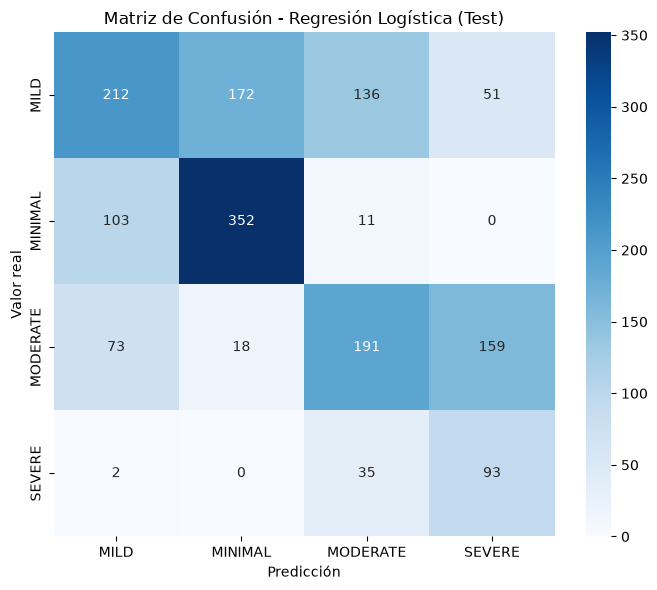

In [9]:
# 1. Tomar el mejor modelo encontrado por el GridSearch
best_model = grid_search.best_estimator_

# 2. Predecir sobre el set de TEST (nunca visto durante el entrenamiento/CV)
y_pred = best_model.predict(X_test_codificado)

# 3. Calcular métricas sobre el test set
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("==============================================")
print("       MÉTRICAS EN TEST (Regresión Logística)  ")
print("==============================================")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 4. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Regresión Logística (Test)')
plt.tight_layout()
plt.show()

In [ ]:
# 1. Definir el modelo base
xgb_model = XGBClassifier(
    random_state=46,
    eval_metric='mlogloss'
    #class_weight='balanced'

)

# 2. Definir la parrilla de hiperparámetros
param_grid = {
    'n_estimators': [50,100, 300, 500,1000],
    'max_depth': range(1,10),
    'learning_rate': [0.01, 0.05, 0.1,0.2],
}

# 3. Configurar GridSearch con Validación Cruzada (5 folds)
grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    n_jobs=-1,
    verbose=1
)

print("--- Iniciando búsqueda de hiperparámetros (Grid Search) ---")

grid_search.fit(X_train_codificado, y_train)

# 4. Ver los mejores resultados
print("\n==============================================")
print("       MEJORES HIPERPARÁMETROS ENCONTRADOS    ")
print("==============================================")
print(grid_search.best_params_)
print(f"Mejor F1 Weighted en Validación Cruzada: {grid_search.best_score_:.4f}")

--- Iniciando búsqueda de hiperparámetros (Grid Search) ---
Fitting 5 folds for each of 180 candidates, totalling 900 fits

       MEJORES HIPERPARÁMETROS ENCONTRADOS    
{'learning_rate': 0.2, 'max_depth': 1, 'n_estimators': 1000}
Mejor F1 Weighted en Validación Cruzada: 0.5760


       MÉTRICAS EN TEST (Regresión Logística)  
Accuracy  : 57.65%
Precision : 57.33%
Recall    : 57.65%
F1 Score  : 56.07%

              precision    recall  f1-score   support

        MILD       0.54      0.45      0.49       571
     MINIMAL       0.68      0.72      0.70       466
    MODERATE       0.53      0.72      0.61       441
      SEVERE       0.51      0.14      0.22       130

    accuracy                           0.58      1608
   macro avg       0.56      0.51      0.50      1608
weighted avg       0.57      0.58      0.56      1608



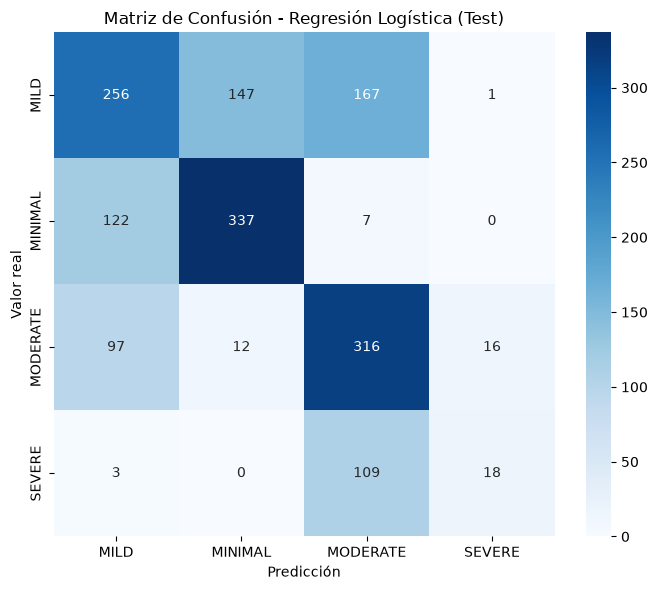

In [11]:
# 1. Tomar el mejor modelo encontrado por el GridSearch
best_model = grid_search.best_estimator_

# 2. Predecir sobre el set de TEST (nunca visto durante el entrenamiento/CV)
y_pred = best_model.predict(X_test_codificado)

# 3. Calcular métricas sobre el test set
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall    = recall_score(y_test, y_pred, average='weighted')
f1        = f1_score(y_test, y_pred, average='weighted')

print("==============================================")
print("       MÉTRICAS EN TEST (Regresión Logística)  ")
print("==============================================")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1 Score  : {f1*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 4. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_
)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Regresión Logística (Test)')
plt.tight_layout()
plt.show()